# Análisis de Respuesta en Frecuencia
## Función de Transferencia
$$H(s) = \frac{40.167}{s^2 + 1.66s + 40.17}$$

[-0.83+6.28339876j -0.83-6.28339876j]


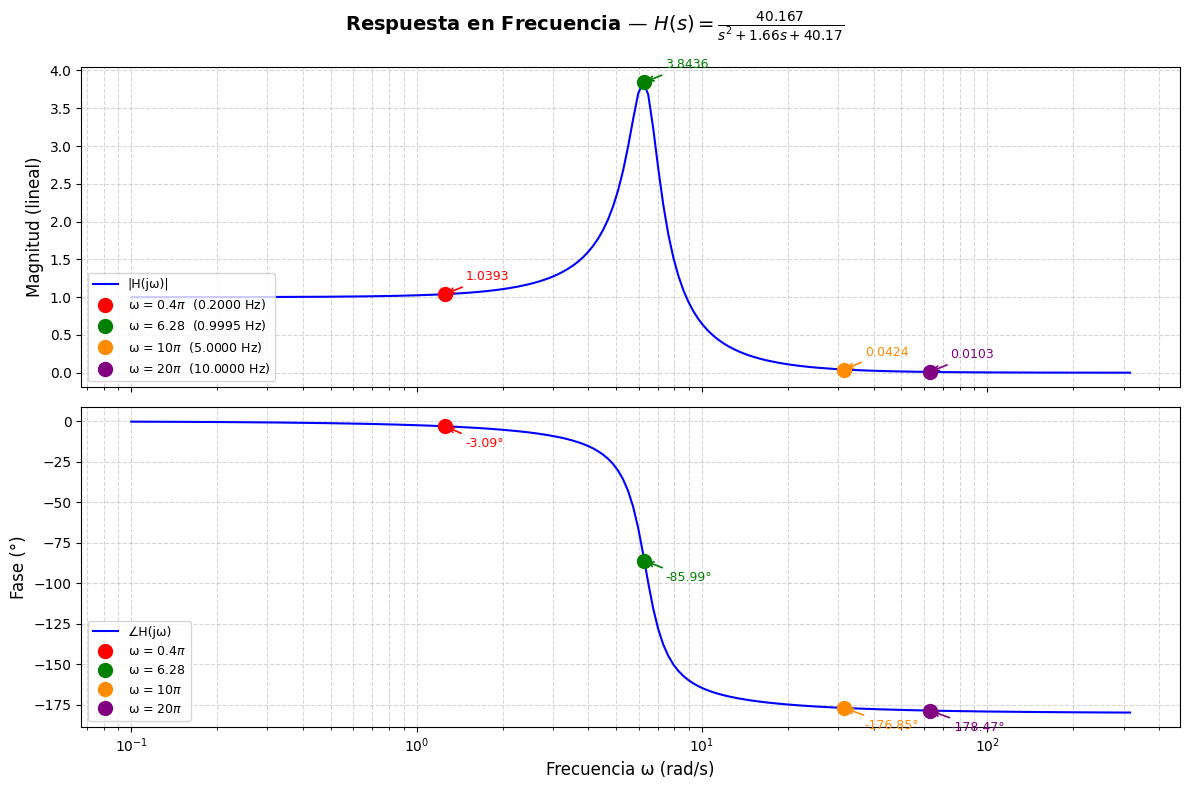

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Definir la función de transferencia H(s) = 40.167 / (s^2 + 1.66s + 40.17)
num = [40.167]
den = [1, 1.66, 40.17]
sistema = signal.TransferFunction(num, den)
print(sistema.poles)
# Rango de frecuencias (rad/s)
w = np.logspace(-1, 2.5, 200)

# Calcular la respuesta en frecuencia
w_out, H = signal.freqresp(sistema, w)

# Magnitud y fase
magnitud = np.abs(H)
magnitud_dB = 20 * np.log10(magnitud)
fase_deg = np.degrees(np.angle(H))

# ============================================================
# Frecuencias de interés
# ============================================================
w_puntos = {
    r'$0.4\pi$':  0.4 * np.pi,
    r'$6.28$':    6.28,
    r'$10\pi$':   10 * np.pi,
    r'$20\pi$':   20 * np.pi,
}

# Evaluar H(jw) en los puntos de interés
w_vals = np.array(list(w_puntos.values()))
_, H_pts = signal.freqresp(sistema, w_vals)

mag_pts     = np.abs(H_pts)
mag_dB_pts  = 20 * np.log10(mag_pts)
fase_pts    = np.degrees(np.angle(H_pts))

# ============================================================
# Diagrama de Magnitud y Fase con puntos resaltados
# ============================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle(r'Respuesta en Frecuencia — $H(s)=\frac{40.167}{s^2+1.66s+40.17}$',
             fontsize=14, fontweight='bold')

# --- Magnitud (lineal) ---
ax1.semilogx(w_out, magnitud, 'b-', linewidth=1.5, label='|H(jω)|')
colors = ['red', 'green', 'darkorange', 'purple']
for i, (etiq, wv) in enumerate(w_puntos.items()):
    ax1.plot(wv, mag_pts[i], 'o', color=colors[i], markersize=10, zorder=5,
             label=f'ω = {etiq}  ({wv/(2*np.pi):.4f} Hz)')
    ax1.annotate(f'{mag_pts[i]:.4f}',
                 xy=(wv, mag_pts[i]),
                 xytext=(15, 10), textcoords='offset points',
                 fontsize=9, color=colors[i],
                 arrowprops=dict(arrowstyle='->', color=colors[i], lw=1.2))

ax1.set_ylabel('Magnitud (lineal)', fontsize=12)
ax1.grid(True, which='both', ls='--', alpha=0.5)
ax1.legend(fontsize=9, loc='lower left')

# --- Fase ---
ax2.semilogx(w_out, fase_deg, 'b-', linewidth=1.5, label='∠H(jω)')
for i, (etiq, wv) in enumerate(w_puntos.items()):
    ax2.plot(wv, fase_pts[i], 'o', color=colors[i], markersize=10, zorder=5,
             label=f'ω = {etiq}')
    ax2.annotate(f'{fase_pts[i]:.2f}°',
                 xy=(wv, fase_pts[i]),
                 xytext=(15, -15), textcoords='offset points',
                 fontsize=9, color=colors[i],
                 arrowprops=dict(arrowstyle='->', color=colors[i], lw=1.2))

ax2.set_ylabel('Fase (°)', fontsize=12)
ax2.set_xlabel('Frecuencia ω (rad/s)', fontsize=12)
ax2.grid(True, which='both', ls='--', alpha=0.5)
ax2.legend(fontsize=9, loc='lower left')

plt.tight_layout()
plt.show()

## Tabla de Valores en las Frecuencias de Interés

In [3]:
# Tabla de resultados usando solo print (sin librerías externas)
etiquetas = ['0.4π', '6.28', '10π', '20π']
w_num     = list(w_puntos.values())

print('Respuesta en Frecuencia de H(s) = 40.167 / (s² + 1.66s + 40.17)')
print('=' * 90)
encabezado = f'{"Frecuencia":^12} {"ω (rad/s)":^12} {"f (Hz)":^12} {"|H(jω)|":^14} {"|H(jω)| dB":^14} {"Fase (°)":^12}'
print(encabezado)
print('-' * 90)
for i in range(len(w_num)):
    fila = (f'{etiquetas[i]:^12} '
            f'{w_num[i]:^12.4f} '
            f'{w_num[i]/(2*np.pi):^12.4f} '
            f'{mag_pts[i]:^14.6f} '
            f'{mag_dB_pts[i]:^14.4f} '
            f'{fase_pts[i]:^12.4f}')
    print(fila)
print('=' * 90)

Respuesta en Frecuencia de H(s) = 40.167 / (s² + 1.66s + 40.17)
 Frecuencia   ω (rad/s)      f (Hz)       |H(jω)|       |H(jω)| dB     Fase (°)  
------------------------------------------------------------------------------------------
    0.4π        1.2566       0.2000       1.040621        0.3458       -1.1823   
    6.28        6.2800       0.9995       9.925301       19.9349       -79.5849  
    10π        31.4159       5.0000       0.042415       -27.4496     -178.7952  
    20π        62.8319      10.0000       0.010278       -39.7614     -179.4161  


## Diagrama de Bode

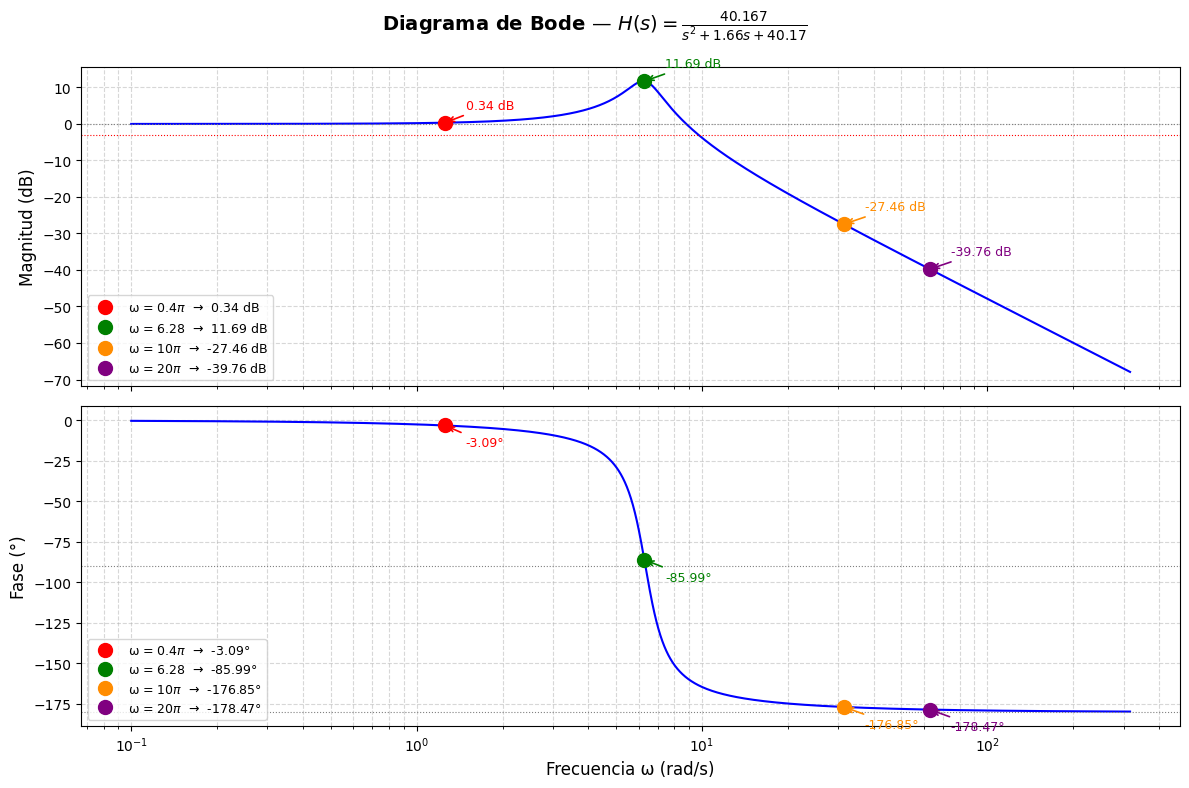

In [7]:
# ============================================================
# Diagrama de Bode usando signal.bode()
# ============================================================
w_bode = np.logspace(-1, 2.5, 2000)
w_b, mag_b, phase_b = signal.bode(sistema, w_bode)

# Evaluar en los puntos de interés para resaltarlos
_, mag_b_pts, phase_b_pts = signal.bode(sistema, w_vals)

fig2, (ax3, ax4) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig2.suptitle(r'Diagrama de Bode — $H(s)=\frac{40.167}{s^2+1.66s+40.17}$',
              fontsize=14, fontweight='bold')

# --- Magnitud (Bode) ---
ax3.semilogx(w_b, mag_b, 'b-', linewidth=1.5)
for i, (etiq, wv) in enumerate(w_puntos.items()):
    ax3.plot(wv, mag_b_pts[i], 'o', color=colors[i], markersize=10, zorder=5,
             label=f'ω = {etiq}  →  {mag_b_pts[i]:.2f} dB')
    ax3.annotate(f'{mag_b_pts[i]:.2f} dB',
                 xy=(wv, mag_b_pts[i]),
                 xytext=(15, 10), textcoords='offset points',
                 fontsize=9, color=colors[i],
                 arrowprops=dict(arrowstyle='->', color=colors[i], lw=1.2))

ax3.set_ylabel('Magnitud (dB)', fontsize=12)
ax3.grid(True, which='both', ls='--', alpha=0.5)
ax3.legend(fontsize=9, loc='lower left')

# Línea de 0 dB y -3 dB
ax3.axhline(y=0, color='gray', linestyle=':', linewidth=0.8)
ax3.axhline(y=-3, color='red', linestyle=':', linewidth=0.8, label='-3 dB')

# --- Fase (Bode) ---
ax4.semilogx(w_b, phase_b, 'b-', linewidth=1.5)
for i, (etiq, wv) in enumerate(w_puntos.items()):
    ax4.plot(wv, phase_b_pts[i], 'o', color=colors[i], markersize=10, zorder=5,
             label=f'ω = {etiq}  →  {phase_b_pts[i]:.2f}°')
    ax4.annotate(f'{phase_b_pts[i]:.2f}°',
                 xy=(wv, phase_b_pts[i]),
                 xytext=(15, -15), textcoords='offset points',
                 fontsize=9, color=colors[i],
                 arrowprops=dict(arrowstyle='->', color=colors[i], lw=1.2))

ax4.set_ylabel('Fase (°)', fontsize=12)
ax4.set_xlabel('Frecuencia ω (rad/s)', fontsize=12)
ax4.grid(True, which='both', ls='--', alpha=0.5)
ax4.legend(fontsize=9, loc='lower left')

# Líneas de referencia de fase
ax4.axhline(y=-90, color='gray', linestyle=':', linewidth=0.8)
ax4.axhline(y=-180, color='gray', linestyle=':', linewidth=0.8)

plt.tight_layout()
plt.show()

